<a href="https://colab.research.google.com/github/sunkaravivek/ML-23CSE302/blob/main/lab-9/9.6_KNN-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip -q /content/digits.zip -d /content/digits_data

In [2]:
import os

print(os.listdir('/content/digits_data'))

['testDigits', 'trainingDigits']


In [3]:
import numpy as np
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [4]:
def img2vector(filename):
    vector = np.zeros((1, 1024))

    with open(filename, 'r') as f:
        for i in range(32):
            line = f.readline()

            for j in range(32):
                vector[0, 32*i + j] = int(line[j])

    return vector

In [5]:
training_path = '/content/digits_data/trainingDigits'

training_files = os.listdir(training_path)

m = len(training_files)

X_train = np.zeros((m, 1024))
y_train = []

for i, filename in enumerate(training_files):

    X_train[i, :] = img2vector(
        os.path.join(training_path, filename)
    )

    label = int(filename.split('_')[0])
    y_train.append(label)

y_train = np.array(y_train)

print("Training samples:", X_train.shape)
print("Labels:", y_train.shape)

Training samples: (1934, 1024)
Labels: (1934,)


In [6]:
test_path = '/content/digits_data/testDigits'

test_files = os.listdir(test_path)

m_test = len(test_files)

X_test = np.zeros((m_test, 1024))
y_test = []

for i, filename in enumerate(test_files):

    X_test[i, :] = img2vector(
        os.path.join(test_path, filename)
    )

    label = int(filename.split('_')[0])
    y_test.append(label)

y_test = np.array(y_test)

print("Testing samples:", X_test.shape)
print("Labels:", y_test.shape)

Testing samples: (946, 1024)
Labels: (946,)


In [7]:
model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [8]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy in Percentage:", int(accuracy * 100), "%")

Accuracy: 0.9883720930232558
Accuracy in Percentage: 98 %


In [9]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 87   0   0   0   0   0   0   0   0   0]
 [  0  96   0   0   0   0   0   1   0   0]
 [  0   0  92   0   0   0   0   0   0   0]
 [  0   0   0  84   0   0   0   0   0   1]
 [  0   0   0   0 114   0   0   0   0   0]
 [  0   0   0   1   0 106   1   0   0   0]
 [  0   0   0   0   0   0  87   0   0   0]
 [  0   0   0   0   0   0   0  96   0   0]
 [  0   3   0   1   0   0   1   0  86   0]
 [  0   1   0   0   0   0   0   1   0  87]]


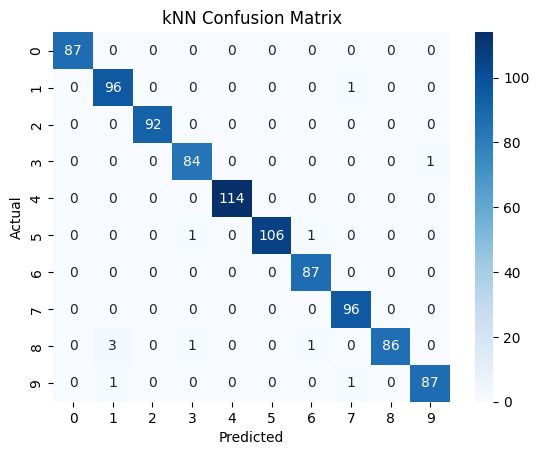

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("kNN Confusion Matrix")

plt.show()

In [10]:
sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)

print("Actual Digit:", y_test[0])
print("Predicted Digit:", prediction[0])

Actual Digit: 1
Predicted Digit: 1
